In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [86]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,paras dews,sector 106,1.34,9550.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up...,4,5,3+,...,2355.0,1535.0,1403.0,0,1,0,0,0,0,49
1,flat,breez global heights,sohna road,0.25,7002.0,357.0,Super Built up area 414(38.46 sq.m.)Carpet are...,1,1,1,...,414.0,NaN,357.0,0,0,0,0,0,0,57
2,flat,signature global park,sohna road,0.90,8035.0,1120.0,Super Built up area 1120(104.05 sq.m.),3,2,2,...,1120.0,NaN,NaN,0,0,0,0,0,0,144
3,flat,corona optus,sector 37c,1.25,7090.0,1763.0,Super Built up area 1763(163.79 sq.m.)Built Up...,3,3,3,...,1763.0,1350.0,1234.0,0,0,0,0,1,0,49
4,flat,ats triumph,sector 104,1.75,7641.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,2290.0,NaN,NaN,0,1,0,0,0,0,110


In [87]:
df.shape

(3803, 24)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   object 
 9   balcony              3803 non-null   object 
 10  floorNum             3784 non-null   float64
 11  facing               2698 non-null   object 
 12  agePossession        3803 non-null   object 
 13  description          3803 non-null   object 
 14  super_built_up_area  1915 non-null   float64
 15  built_up_area        1733 non-null   f

In [89]:
df.duplicated().sum()

126

In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,paras dews,sector 106,1.34,9550.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up...,4,5,3+,...,2355.0,1535.0,1403.0,0,1,0,0,0,0,49
1,flat,breez global heights,sohna road,0.25,7002.0,357.0,Super Built up area 414(38.46 sq.m.)Carpet are...,1,1,1,...,414.0,NaN,357.0,0,0,0,0,0,0,57
2,flat,signature global park,sohna road,0.90,8035.0,1120.0,Super Built up area 1120(104.05 sq.m.),3,2,2,...,1120.0,NaN,NaN,0,0,0,0,0,0,144
3,flat,corona optus,sector 37c,1.25,7090.0,1763.0,Super Built up area 1763(163.79 sq.m.)Built Up...,3,3,3,...,1763.0,1350.0,1234.0,0,0,0,0,1,0,49
4,flat,ats triumph,sector 104,1.75,7641.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,2290.0,NaN,NaN,0,1,0,0,0,0,110


### property_type

<Axes: xlabel='property_type'>

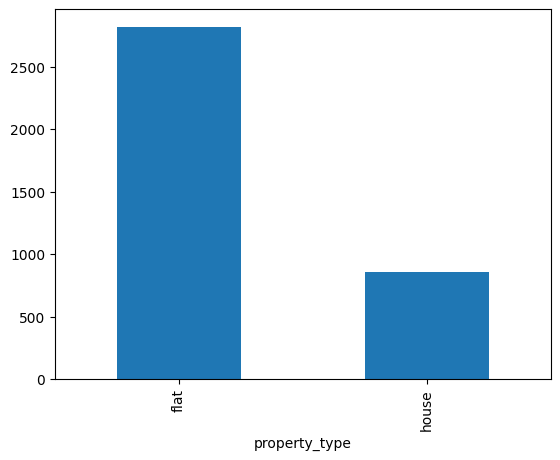

In [92]:
df['property_type'].value_counts().plot(kind='bar',)

### society

In [94]:
df['society'].value_counts().shape

(676,)

In [95]:
df['society'].value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
dlf new town heights                     42
shapoorji pallonji joyville gurugram     42
                                       ... 
m3m golf hills phase 1                    1
g l s arawali homes                       1
adani oyster greens                       1
shivaji nagar residential                 1
park view apartments                      1
Name: count, Length: 676, dtype: int64

In [96]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023511
ss the leaf                             0.046395
shapoorji pallonji joyville gurugram    0.059561
dlf new town heights                    0.072727
signature global park                   0.083699
                                          ...   
ansal heights 86                        0.490282
indiabulls enigma                       0.494357
ats kocoon                              0.498433
ireo the corridors                      0.502194
central park flower valley              0.505956
Name: proportion, Length: 75, dtype: float64

In [97]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': 1,
 'High (50-100)': 2,
 'Average (10-49)': 92,
 'Low (2-9)': 273,
 'Very Low (1)': 308}

<Axes: xlabel='society'>

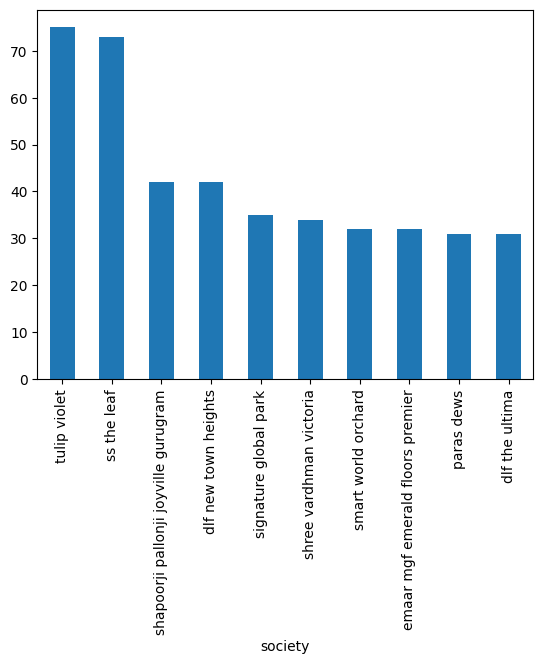

In [98]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [99]:
df['society'].isnull().sum()

1

In [100]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1349,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


### sector

In [101]:
df['sector'].value_counts().shape

(115,)

<Axes: xlabel='sector'>

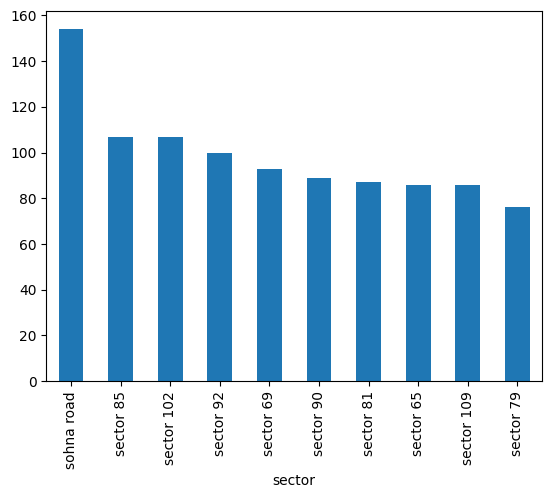

In [102]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [103]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins


{'Very High (>100)': 3,
 'High (50-100)': 25,
 'Average (10-49)': 63,
 'Low (2-9)': 23,
 'Very Low (1)': 1}

### price

In [104]:
df['price'].isnull().sum()

17

In [105]:
df['price'].describe()

count    3660.000000
mean        2.533664
std         2.980623
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

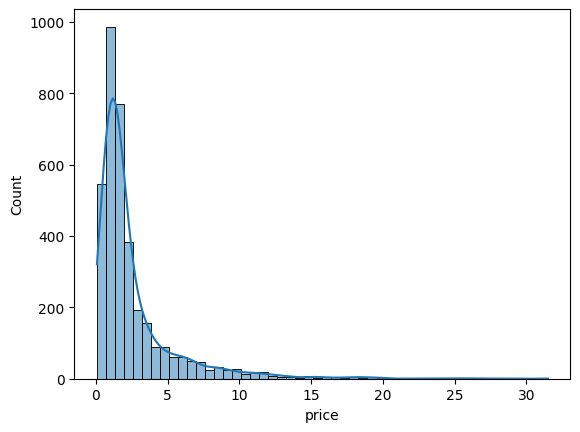

In [106]:
sns.histplot(df['price'], kde=True, bins=50)

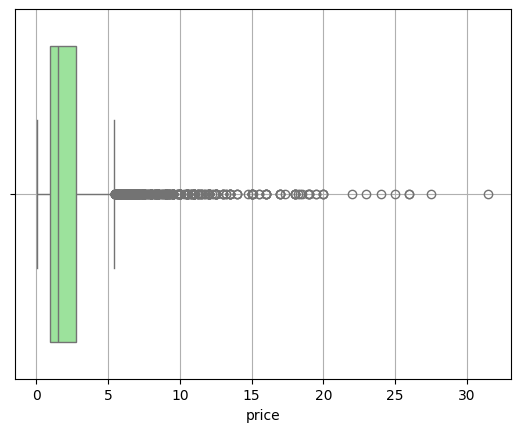

In [107]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

In [108]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.2791704733134615 14.933372629214254


In [109]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.264
Name: price, dtype: float64

In [110]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

1.8

In [111]:

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [112]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 24)

In [113]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

<Axes: xlabel='price'>

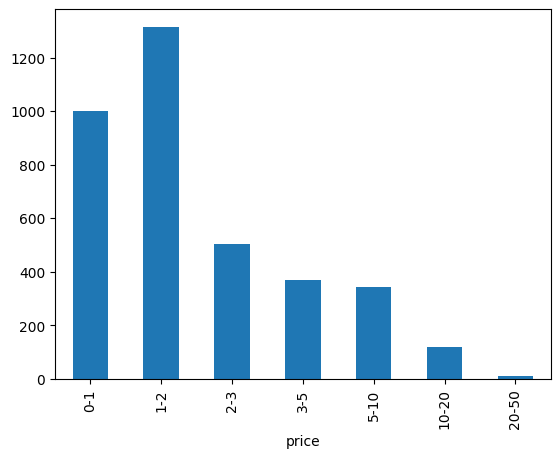

In [114]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

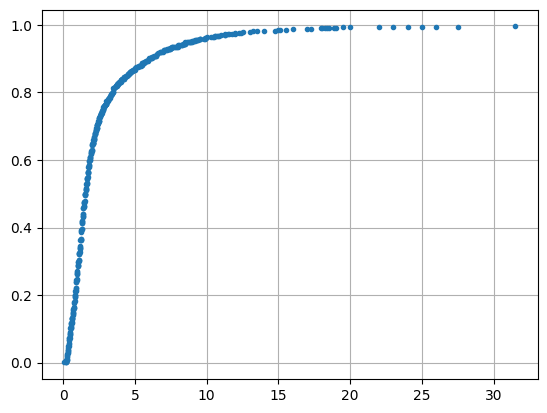

In [115]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

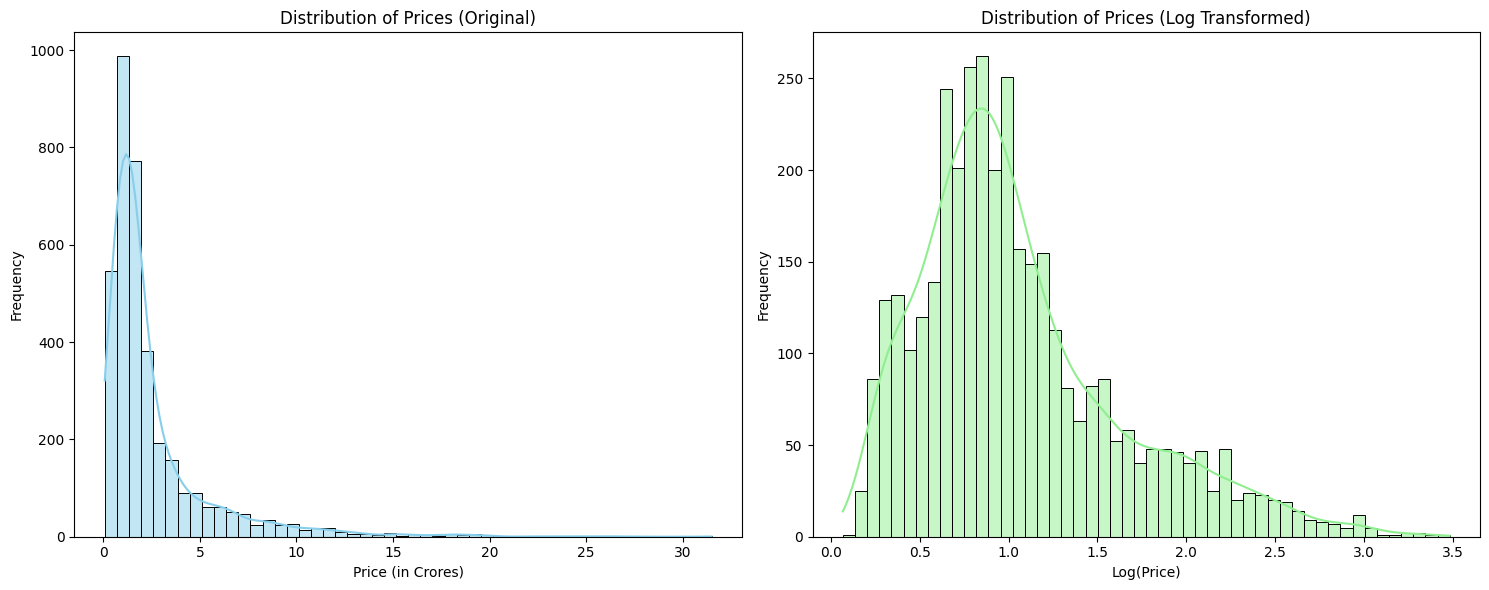

In [116]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [117]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0740709565255313 0.9646692415449274


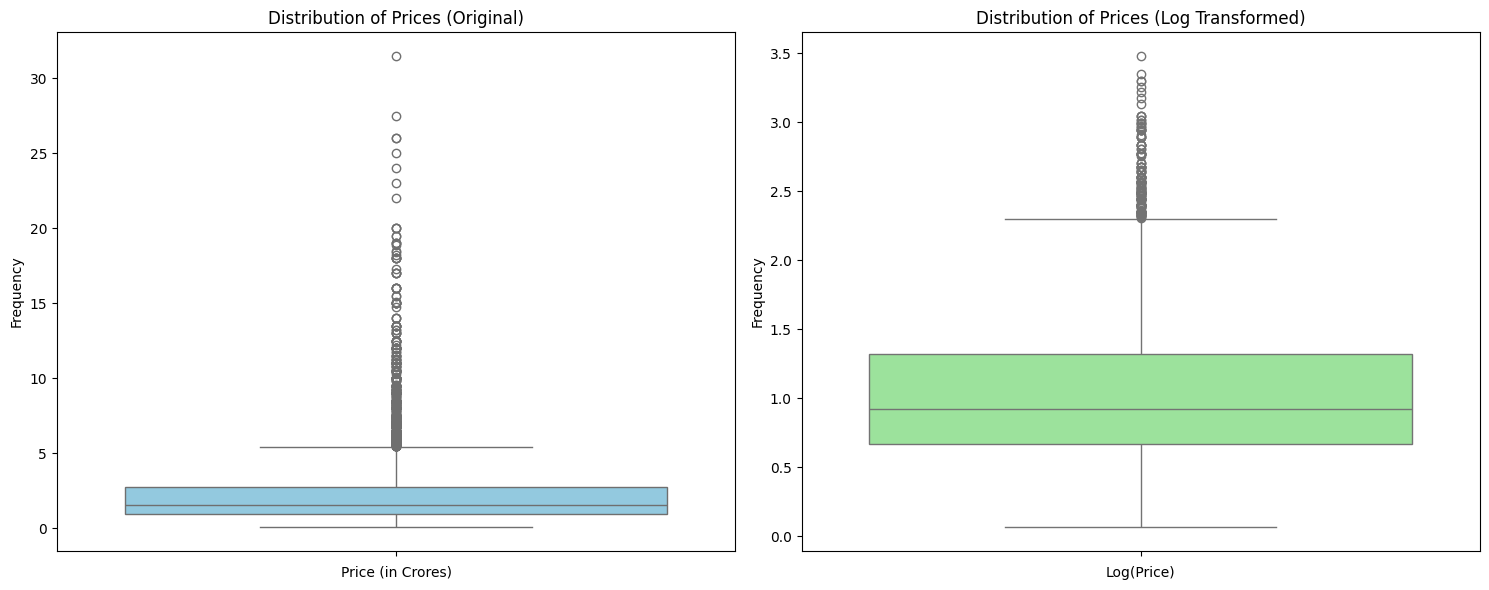

In [118]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### price_per_sqft

In [119]:
df['price_per_sqft'].isnull().sum()

17

In [120]:
df['price_per_sqft'].describe()

count      3660.000000
mean      13892.668306
std       23210.067190
min           4.000000
25%        6817.250000
50%        9020.000000
75%       13880.500000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

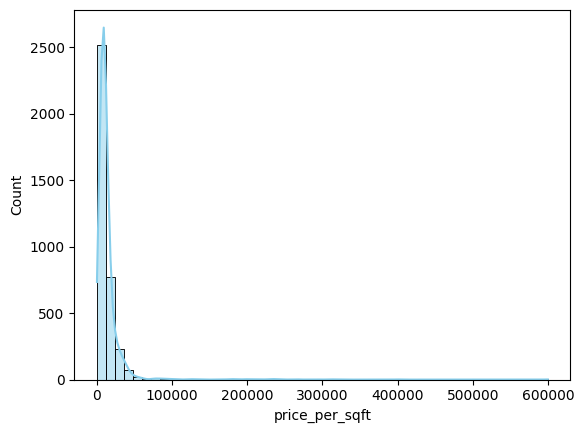

In [121]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

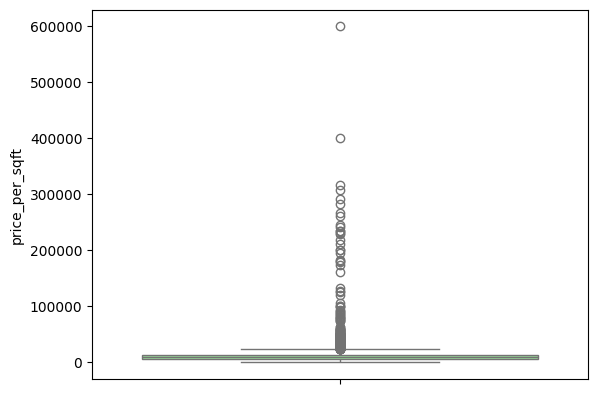

In [122]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')

### bedroom

In [123]:
df['bedRoom'].isnull().sum()

0

<Axes: xlabel='bedRoom'>

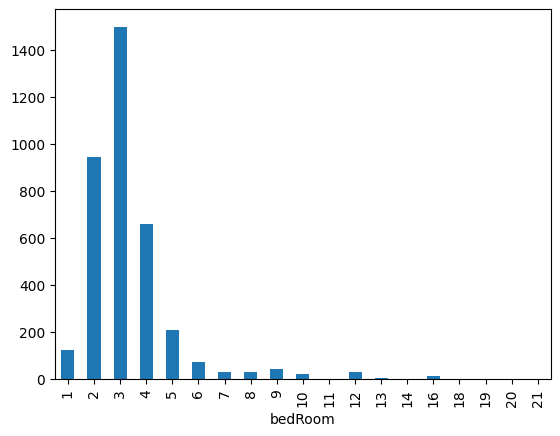

In [124]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

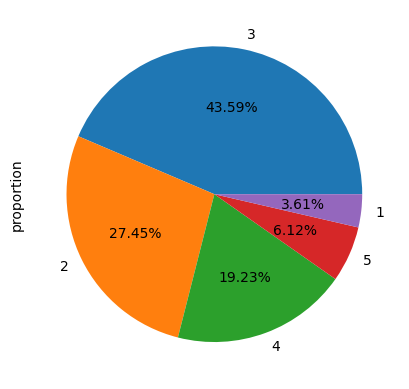

In [125]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### bathroom

In [126]:
df['bathroom'].isnull().sum()

0

<Axes: xlabel='bathroom'>

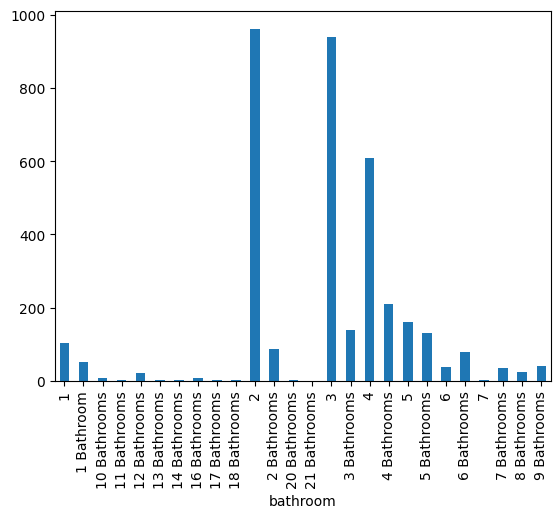

In [129]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

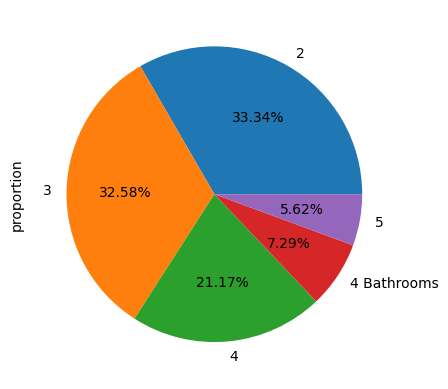

In [130]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [131]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,paras dews,sector 106,1.34,9550.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up...,4,5,3+,...,2355.0,1535.0,1403.0,0,1,0,0,0,0,49
1,flat,breez global heights,sohna road,0.25,7002.0,357.0,Super Built up area 414(38.46 sq.m.)Carpet are...,1,1,1,...,414.0,NaN,357.0,0,0,0,0,0,0,57
2,flat,signature global park,sohna road,0.90,8035.0,1120.0,Super Built up area 1120(104.05 sq.m.),3,2,2,...,1120.0,NaN,NaN,0,0,0,0,0,0,144
3,flat,corona optus,sector 37c,1.25,7090.0,1763.0,Super Built up area 1763(163.79 sq.m.)Built Up...,3,3,3,...,1763.0,1350.0,1234.0,0,0,0,0,1,0,49
4,flat,ats triumph,sector 104,1.75,7641.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,2290.0,NaN,NaN,0,1,0,0,0,0,110


### balcony

In [132]:
df['balcony'].isnull().sum()

0

<Axes: xlabel='balcony'>

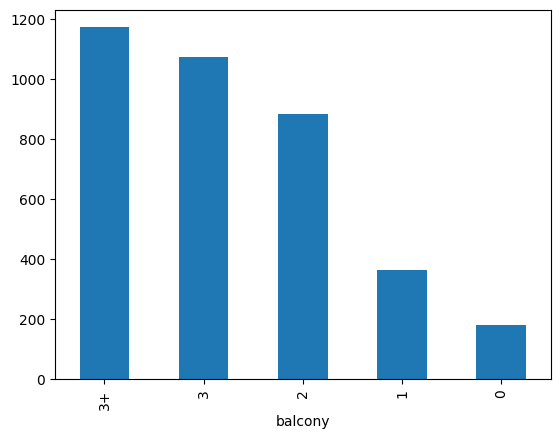

In [133]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

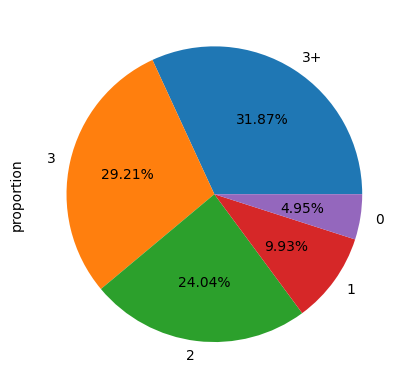

In [134]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### floorNum

In [135]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,7.0,South-East,Relatively New,"This 4 bhk flat is located in paras dews, whic...",2355.0,1535.0,1403.0,0,1,0,0,0,0,49
1,1.0,NaN,Relatively New,The property is registered and freehold. The b...,414.0,NaN,357.0,0,0,0,0,0,0,57
2,2.0,South,Under Construction,We are the proud owners of this 3 bhk apartmen...,1120.0,NaN,NaN,0,0,0,0,0,0,144
3,4.0,North-West,Relatively New,Optus corona is a ready to move residential pr...,1763.0,1350.0,1234.0,0,0,0,0,1,0,49
4,11.0,South-East,Relatively New,"This 3 bhk flat is located in ats triumph, whi...",2290.0,NaN,NaN,0,1,0,0,0,0,110


In [136]:
df['floorNum'].isnull().sum()

19

In [137]:
df['floorNum'].describe()

count    3658.000000
mean        6.798250
std         6.012454
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

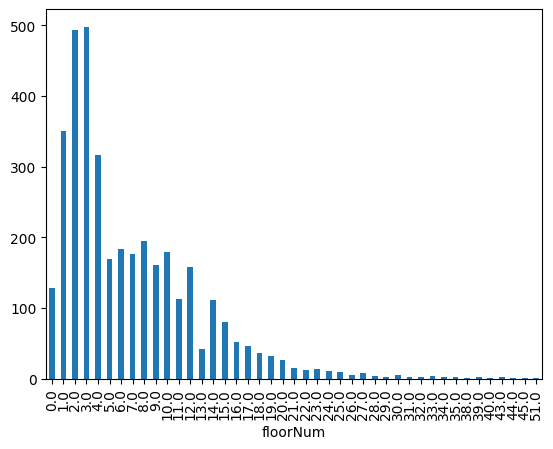

In [138]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

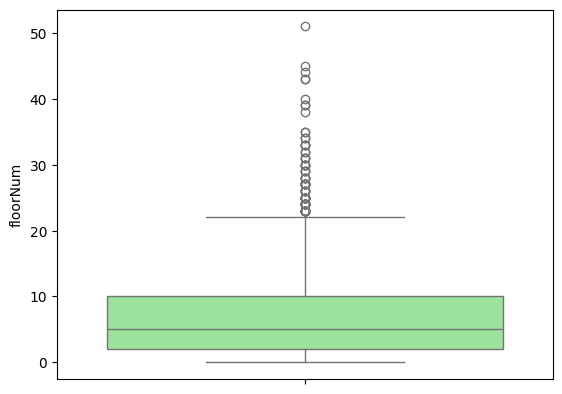

In [139]:
sns.boxplot(df['floorNum'], color='lightgreen')

### facing

In [140]:
df['facing'].isnull().sum()

1045

In [141]:
df['facing'].fillna('NA',inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_3968\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [142]:
df['facing'].value_counts()

facing
NA            1045
North-East     623
East           623
North          387
West           249
South          231
North-West     193
South-East     173
South-West     153
Name: count, dtype: int64

### agePossession

In [143]:
df['agePossession'].isnull().sum()

0

In [144]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         563
Undefined              306
Old Property           303
Under Construction     266
Name: count, dtype: int64

### areas

In [145]:
# super built up area
df['super_built_up_area'].isnull().sum()

1802

In [146]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

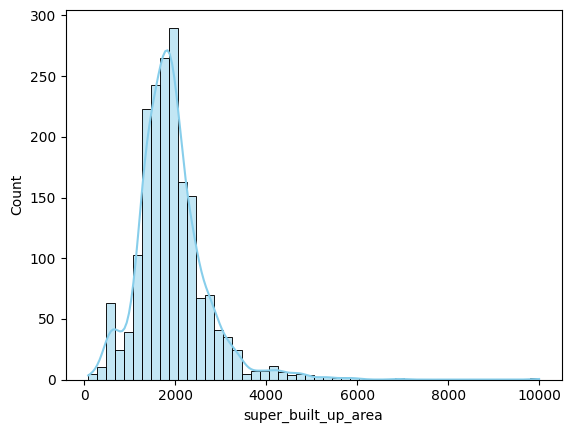

In [147]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

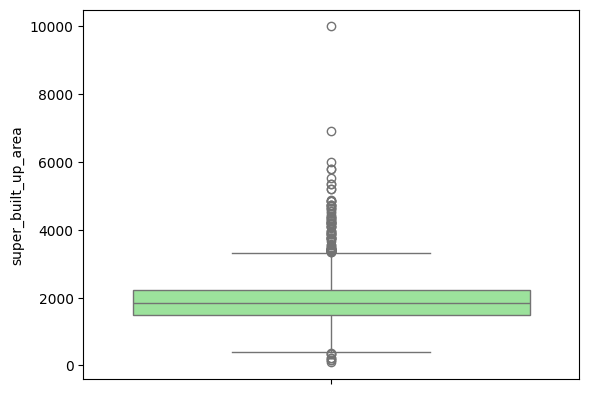

In [148]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

In [149]:
# built up area
df['built_up_area'].isnull().sum()

1987

In [150]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

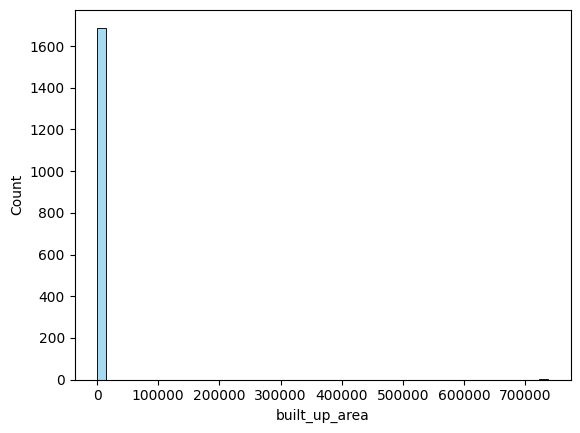

In [151]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

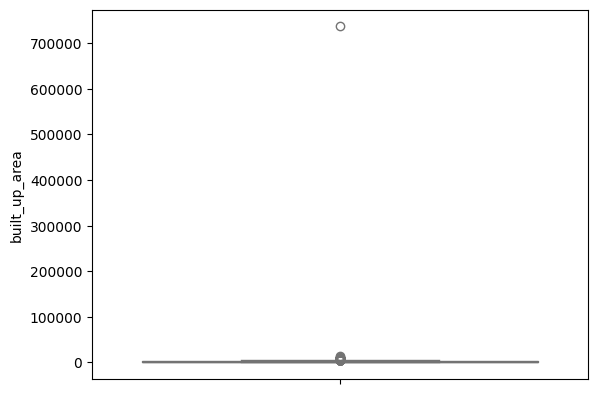

In [152]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

In [153]:
# carpet area
df['carpet_area'].isnull().sum()

1805

In [154]:
df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

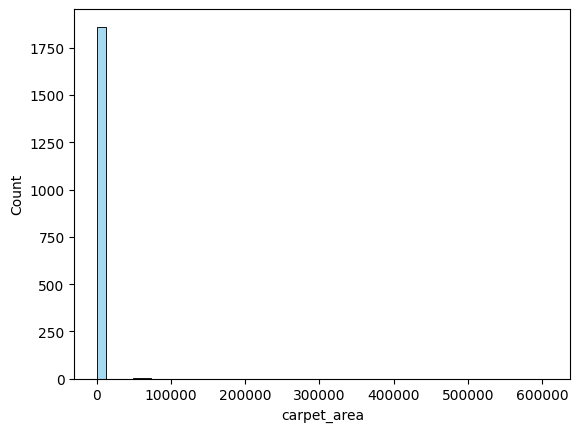

In [155]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

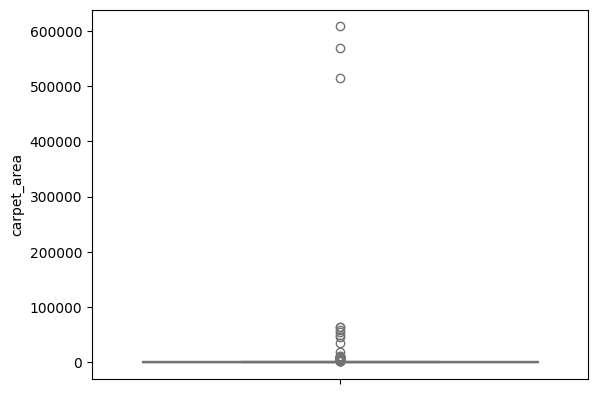

In [156]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [157]:
df.iloc[:,16:]

,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,1403.0,0,1,0,0,0,0,49
1,357.0,0,0,0,0,0,0,57
2,NaN,0,0,0,0,0,0,144
3,1234.0,0,0,0,0,1,0,49
4,NaN,0,1,0,0,0,0,110
...,...,...,...,...,...,...,...,...
3797,3600.0,1,1,0,1,1,2,49
3798,1177.0,0,0,0,0,0,2,97
3800,NaN,0,1,0,0,0,0,99
3801,1650.0,0,1,0,0,0,0,165


### additional rooms

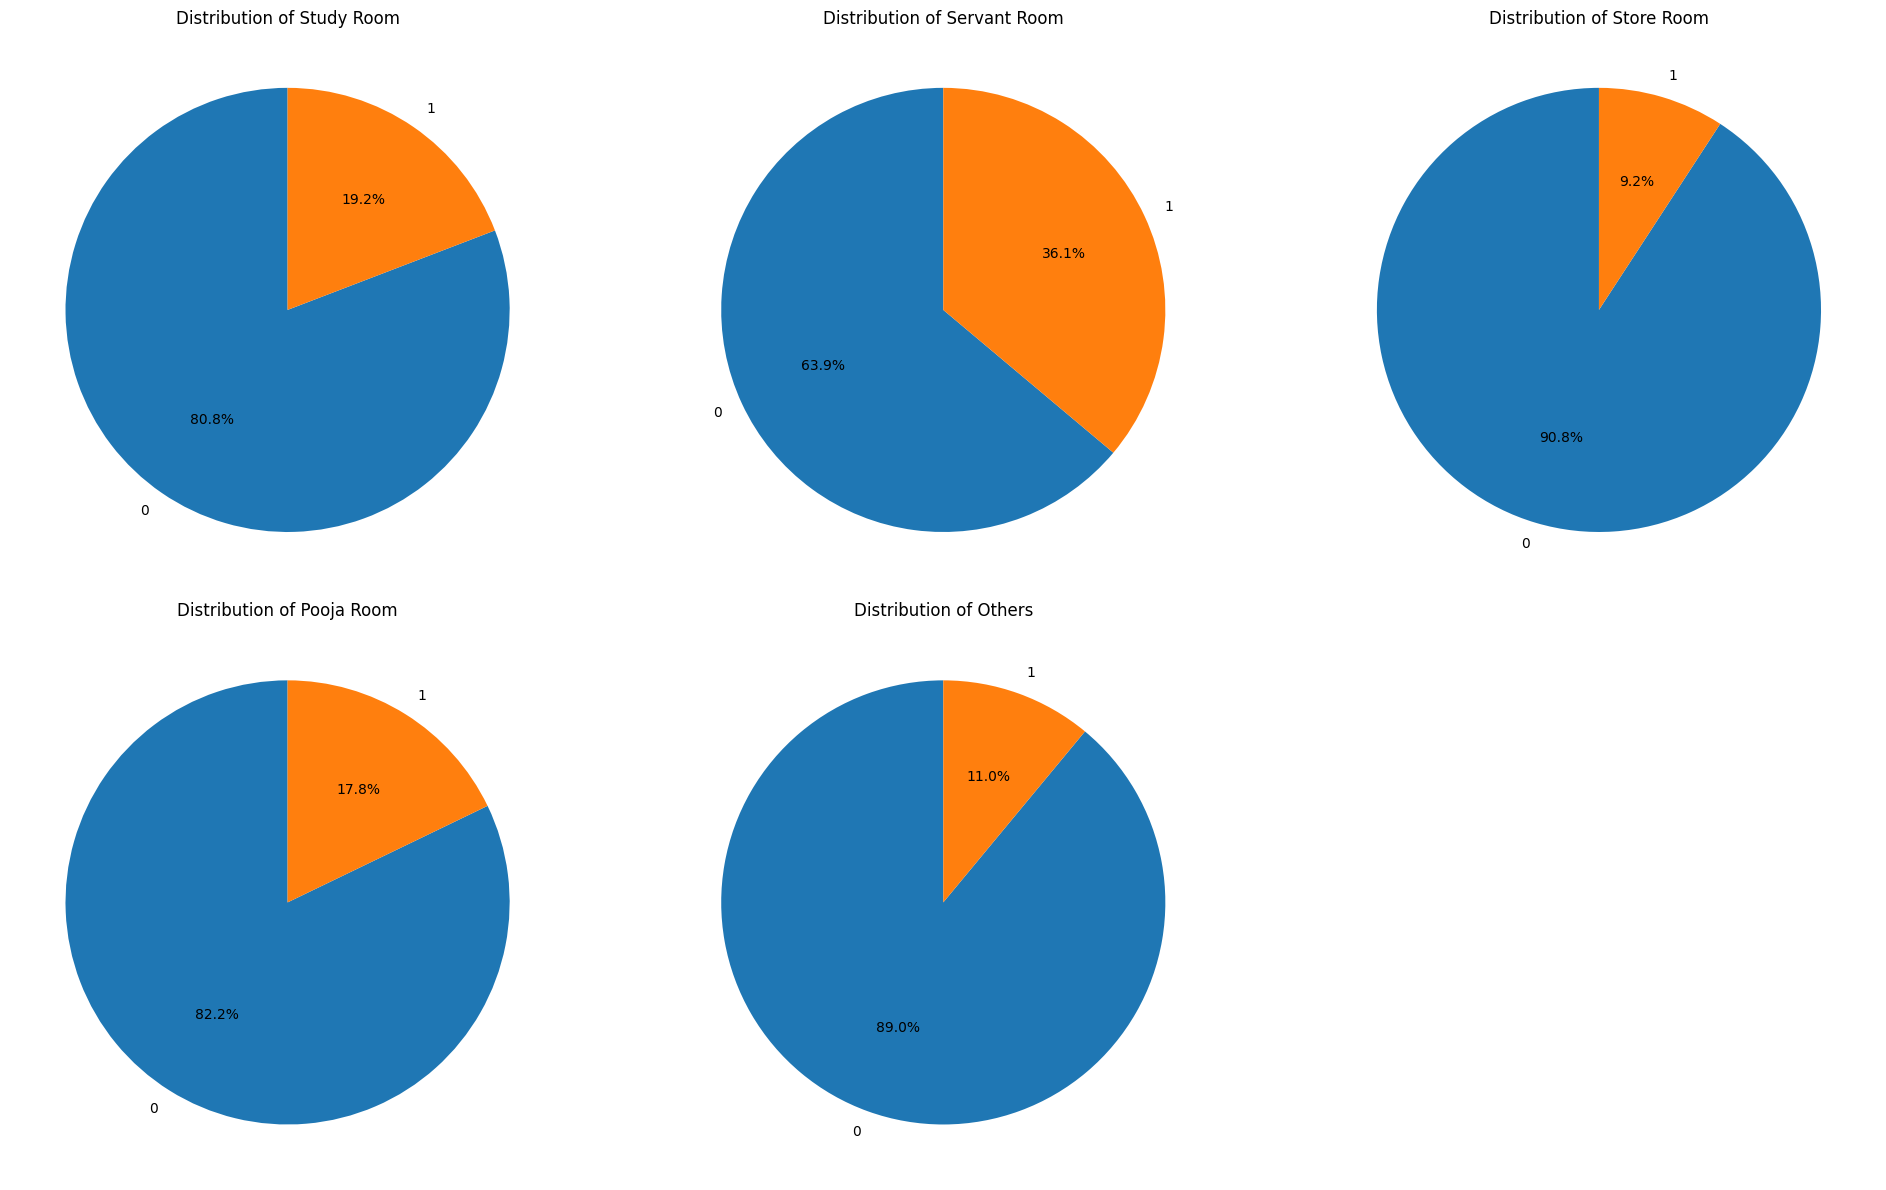

In [158]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### furnishing_type

In [160]:
df['furnishing_type'].value_counts()

furnishing_type
0    2403
2    1062
1     212
Name: count, dtype: int64

<Axes: ylabel='count'>

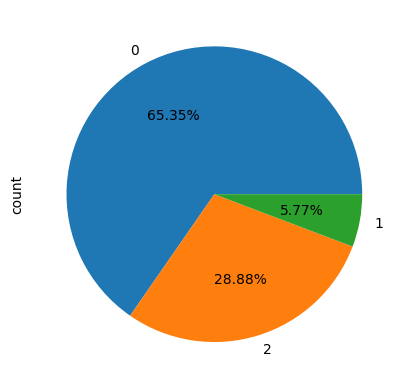

In [161]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

### luxury score

In [162]:
df['luxury_score'].isnull().sum()

0

In [163]:
df['luxury_score'].describe()

count    3677.000000
mean       71.512918
std        53.059082
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

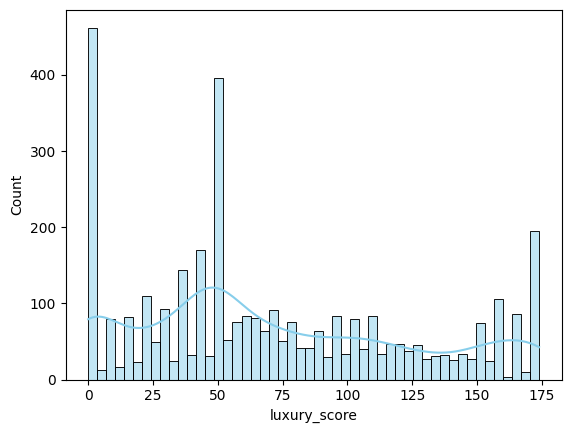

In [164]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

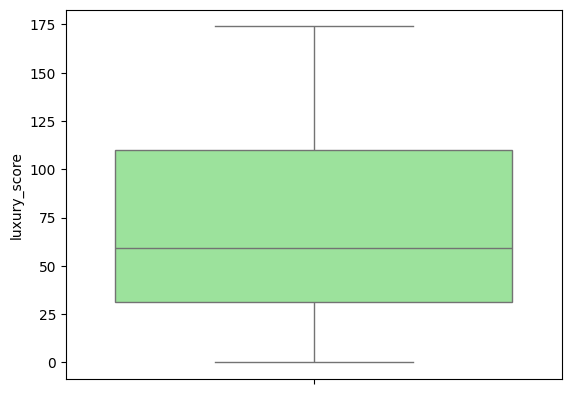

In [165]:
sns.boxplot(df['luxury_score'], color='lightgreen')

In [166]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,paras dews,sector 106,1.34,9550.0,1403.0,Super Built up area 2355(218.79 sq.m.)Built Up...,4,5,3+,...,2355.0,1535.0,1403.0,0,1,0,0,0,0,49
1,flat,breez global heights,sohna road,0.25,7002.0,357.0,Super Built up area 414(38.46 sq.m.)Carpet are...,1,1,1,...,414.0,NaN,357.0,0,0,0,0,0,0,57
2,flat,signature global park,sohna road,0.90,8035.0,1120.0,Super Built up area 1120(104.05 sq.m.),3,2,2,...,1120.0,NaN,NaN,0,0,0,0,0,0,144
3,flat,corona optus,sector 37c,1.25,7090.0,1763.0,Super Built up area 1763(163.79 sq.m.)Built Up...,3,3,3,...,1763.0,1350.0,1234.0,0,0,0,0,1,0,49
4,flat,ats triumph,sector 104,1.75,7641.0,2290.0,Super Built up area 2290(212.75 sq.m.),3,4,3+,...,2290.0,NaN,NaN,0,1,0,0,0,0,110
